In [20]:
import numpy as np
import pandas as pandas
from sklearn.datasets import make_classification

In [21]:
X, y = make_classification(n_features=5, n_redundant=0, n_informative=5, n_clusters_per_class=1)

In [22]:
df = pandas.DataFrame(X, columns=['feature1', 'feature2', 'feature3', 'feature4', 'feature5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,feature1,feature2,feature3,feature4,feature5,target
0,0.581312,-0.249782,0.908744,0.928168,0.921331,1
1,2.485478,-2.159271,-0.661160,-2.313338,-2.670462,0
2,0.958909,0.220732,-0.065293,-0.939189,0.171826,0
3,0.058614,-1.225039,-2.466586,-0.496766,-0.498674,0
4,0.253613,-0.185321,0.192085,-0.801397,-0.304157,0


In [68]:
#Row Sampling

import random


def sample_rows(df, percent):
    return df.sample(int(percent*df.shape[0]),replace=True)

#Column Sampling
def sample_columns(df, percent):
    cols = random.sample(df.columns.tolist()[:-1], int(percent*(df.shape[1]-1)))
    new_df = df[cols]
    new_df['target'] = df['target']
    return new_df

#Combining Row and Column Sampling
def combined_sampling(df, row_percent, col_percent):
    new_df = sample_rows(df, row_percent)
    return sample_columns(new_df, col_percent)

In [24]:
#100% Row Sampling
df1 = sample_rows(df, 0.1)
print(df1.shape)
#Randomly Sample of 10% of the rows

(10, 6)


In [25]:
df2 = sample_rows(df, 0.1)
print(df2.shape)

(10, 6)


In [26]:
df3 = sample_rows(df, 0.1)
print(df3.shape)

(10, 6)


In [27]:
from sklearn.tree import DecisionTreeClassifier
cl1 = DecisionTreeClassifier()
cl2 = DecisionTreeClassifier()
cl3 = DecisionTreeClassifier()

In [28]:
cl1.fit(df1.drop('target', axis=1), df1['target'])
cl2.fit(df2.drop('target', axis=1), df2['target'])  
cl3.fit(df3.drop('target', axis=1), df3['target'])

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.5, 0.75, 'x[2] <= -0.017\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.625, 0.5, '  False')]

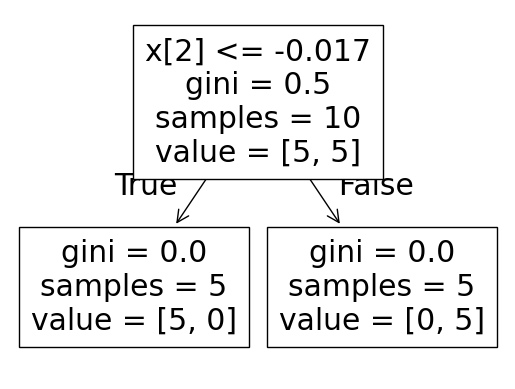

In [29]:
from sklearn.tree import plot_tree
plot_tree(cl1)

[Text(0.5, 0.75, 'x[2] <= -0.967\ngini = 0.42\nsamples = 10\nvalue = [3, 7]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 7\nvalue = [0, 7]'),
 Text(0.625, 0.5, '  False')]

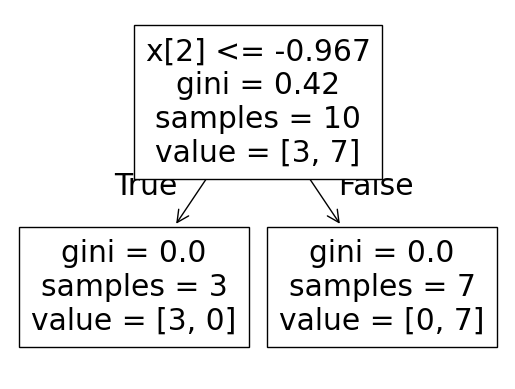

In [30]:
plot_tree(cl2)

[Text(0.4, 0.8333333333333334, 'x[4] <= 0.99\ngini = 0.48\nsamples = 10\nvalue = [6, 4]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[0] <= -2.237\ngini = 0.32\nsamples = 5\nvalue = [1, 4]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]')]

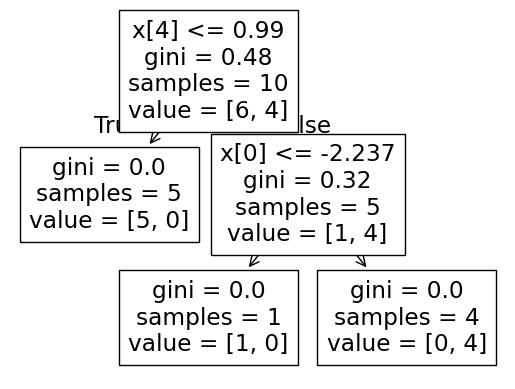

In [31]:
plot_tree(cl3)

In [ ]:
#test with point first tree
cl1.predict(np.array([-0.145272,	1.269203,	-0.446821,	-0.907821,	3.300772]).reshape(1,5))

d:\AIML\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [35]:
#test with point second tree
cl2.predict(np.array([-0.145272,	1.269203,	-0.446821,	-0.907821,	3.300772]).reshape(1,5))

d:\AIML\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [36]:
#test with point first tree
cl3.predict(np.array([-0.145272,	1.269203,	-0.446821,	-0.907821,	3.300772]).reshape(1,5))

d:\AIML\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [70]:
df1_col = sample_columns(df, 0.8)
df2_col = sample_columns(df, 0.8)
df3_col = sample_columns(df, 0.8)

C:\Users\Ravijot\AppData\Local\Temp\ipykernel_996\2297247121.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']
C:\Users\Ravijot\AppData\Local\Temp\ipykernel_996\2297247121.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']
C:\Users\Ravijot\AppData\Local\Temp\ipykernel_996\2297247121.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See

In [60]:
from sklearn.tree import DecisionTreeClassifier
cl1_col = DecisionTreeClassifier()
cl2_col = DecisionTreeClassifier()
cl3_col = DecisionTreeClassifier()

In [71]:
print(df1_col.shape)
print(df2_col.shape)
print(df3_col.shape)

(100, 5)
(100, 5)
(100, 5)


In [72]:
cl1_col.fit(df1_col.iloc[:,0:3] , df1_col.iloc[:,-1])
cl2_col.fit(df2_col.iloc[:,0:3] , df2_col.iloc[:,-1])  
cl3_col.fit(df3_col.iloc[:,0:3] , df3_col.iloc[:,-1])

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.5277777777777778, 0.9166666666666666, 'x[2] <= -0.564\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.2777777777777778, 0.75, 'x[0] <= 2.248\ngini = 0.263\nsamples = 45\nvalue = [38, 7]'),
 Text(0.4027777777777778, 0.8333333333333333, 'True  '),
 Text(0.1111111111111111, 0.5833333333333334, 'x[2] <= -0.892\ngini = 0.102\nsamples = 37\nvalue = [35, 2]'),
 Text(0.05555555555555555, 0.4166666666666667, 'gini = 0.0\nsamples = 31\nvalue = [31, 0]'),
 Text(0.16666666666666666, 0.4166666666666667, 'x[1] <= -1.545\ngini = 0.444\nsamples = 6\nvalue = [4, 2]'),
 Text(0.1111111111111111, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.2222222222222222, 0.25, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.4444444444444444, 0.5833333333333334, 'x[2] <= -1.576\ngini = 0.469\nsamples = 8\nvalue = [3, 5]'),
 Text(0.3888888888888889, 0.4166666666666667, 'x[2] <= -2.723\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.3333333333333333, 0.25, 'gini = 0.0\nsamples = 1\n

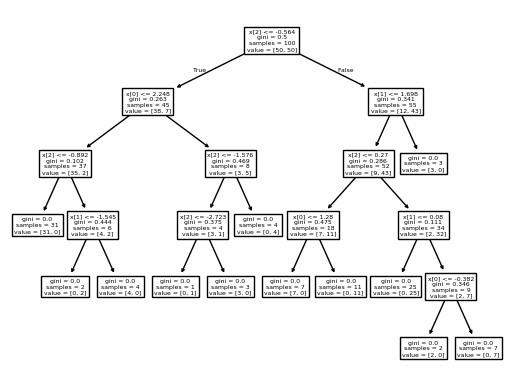

In [75]:
from sklearn.tree import plot_tree
plot_tree(cl1_col)

[Text(0.53125, 0.9285714285714286, 'x[2] <= -0.403\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.25, 0.7857142857142857, 'x[0] <= -0.07\ngini = 0.162\nsamples = 45\nvalue = [41, 4]'),
 Text(0.390625, 0.8571428571428572, 'True  '),
 Text(0.125, 0.6428571428571429, 'x[1] <= 1.005\ngini = 0.053\nsamples = 37\nvalue = [36, 1]'),
 Text(0.0625, 0.5, 'gini = 0.0\nsamples = 34\nvalue = [34, 0]'),
 Text(0.1875, 0.5, 'x[0] <= -1.857\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.125, 0.35714285714285715, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.25, 0.35714285714285715, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.375, 0.6428571428571429, 'x[0] <= 0.168\ngini = 0.469\nsamples = 8\nvalue = [5, 3]'),
 Text(0.3125, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.4375, 0.5, 'x[2] <= -1.428\ngini = 0.408\nsamples = 7\nvalue = [5, 2]'),
 Text(0.375, 0.35714285714285715, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.5, 0.35714285714285715, 'x[0] <= 1.101

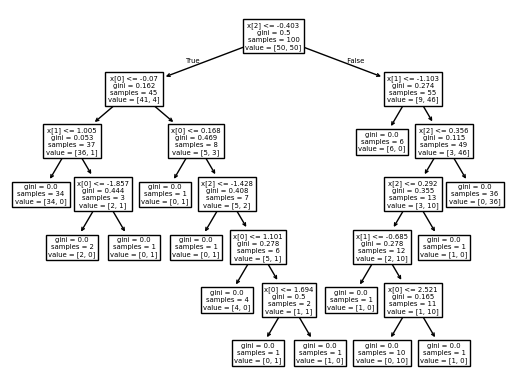

In [77]:
plot_tree(cl2_col)

In [84]:
#test with point first tree
cl1_col.predict(np.array([-0.145272,	1.269203,	-0.446821]).reshape(1,3))

d:\AIML\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [85]:
#test with point second tree
cl2_col.predict(np.array([-0.145272,	1.269203,	-0.446821]).reshape(1,3))

d:\AIML\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [86]:
#test with point third tree
cl3_col.predict(np.array([-0.145272,	1.269203,	-0.446821]).reshape(1,3))

d:\AIML\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])